# Coding Task: Comparing Optimization Algorithms for Linear Regression

**Goal:** Implement and compare different optimisation methods (Gradient Descent, Newton’s Method, PSO, Grid Search) for linear regression.

## Dataset

We will use a synthetic 1D dataset with added noise:

\[
y = 2.5x + 1.3 + \epsilon,\quad \epsilon \sim \mathcal{N}(0, 0.5^2)
\]

- Generate 50 training points where `x` is uniformly spaced in `[0, 5]`.
- Generate 200 test points for evaluation.

## What You Will Do

1. Implement **linear regression** using the closed‑form normal equation (baseline).
2. Implement **Gradient Descent** from scratch (full batch) with:
   - Different learning rates
   - Different numbers of iterations
   - Plot cost history
3. Implement **Newton’s Method** (same cost function, use Hessian) and compare convergence speed.
4. Use **Grid Search** and **Random Search** to tune hyperparameters (learning rate, number of iterations, maybe regularisation) for a scikit‑learn `SGDRegressor`.
5. (Optional) Implement **Particle Swarm Optimisation (PSO)** to minimise the cost function.
6. Compare all methods in terms of:
   - Final cost (MSE)
   - Number of iterations / time to converge
   - Sensitivity to hyperparameters

## Questions

1. Which optimisation method converges fastest (fewest iterations) and why?
2. How does the choice of learning rate affect gradient descent? Show plots.
3. What are the advantages and disadvantages of Newton’s method for linear regression?
4. Compare Grid Search vs Random Search: which is more efficient when you have 3+ hyperparameters?
5. (Optional) PSO vs gradient descent – which is easier to implement and which finds a better minimum?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_squared_error
from scipy.optimize import minimize

# Generate synthetic data
np.random.seed(42)
N_train = 50
x_train = np.linspace(0, 5, N_train).reshape(-1, 1)
y_train = 2.5 * x_train.flatten() + 1.3 + np.random.normal(0, 0.5, N_train)

N_test = 200
x_test = np.linspace(0, 5, N_test).reshape(-1, 1)
y_test = 2.5 * x_test.flatten() + 1.3 + np.random.normal(0, 0.5, N_test)

# Add bias column (x0 = 1)
X_train = np.c_[np.ones(N_train), x_train.flatten()]
X_test = np.c_[np.ones(N_test), x_test.flatten()]

print(f"Training shape: {X_train.shape}, Test shape: {X_test.shape}")

Training shape: (50, 2), Test shape: (200, 2)


In [15]:
def normal_equation(X, y):
    """Compute weights analytically: w = (X^T X)^{-1} X^T y"""
    return np.linalg.inv(X.T @ X) @ X.T @ y

w_closed = normal_equation(X_train, y_train)
y_pred_closed = X_test @ w_closed
mse_closed = mean_squared_error(y_test, y_pred_closed)
print(f"Closed-form MSE: {mse_closed:.6f}")
print(f"Closed-form weights: w0 = {w_closed[0]:.6f}, w1 = {w_closed[1]:.6f}")

Closed-form MSE: 0.261969
Closed-form weights: w0 = 1.332222, w1 = 2.442017


LR = 0.1: final weights = [1.33222155 2.4420166 ], final cost = 0.206285
LR = 0.01: final weights = [1.2819652  2.45737195], final cost = 0.206944
LR = 0.001: final weights = [0.9088757  2.57109688], final cost = 0.252587


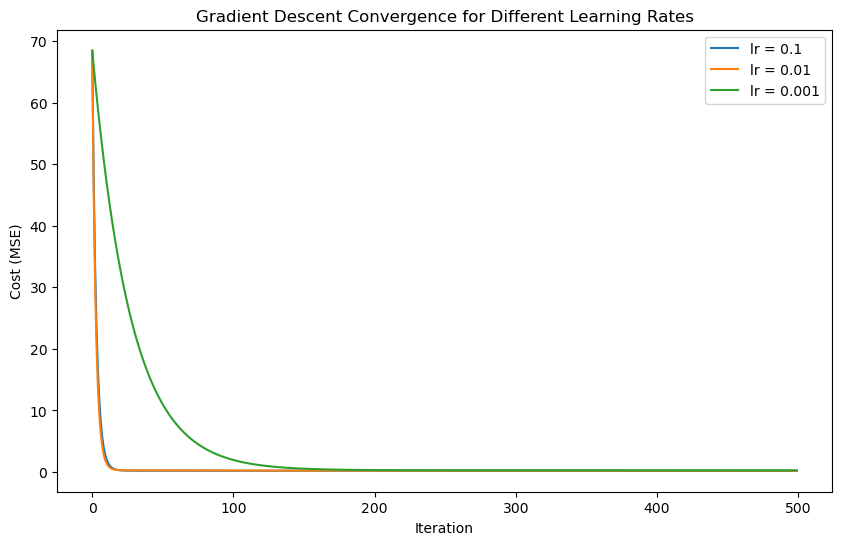


Best GD weights: w0 = 1.332222, w1 = 2.442017


In [17]:
def cost_gradient(X, y, w):
    """Return MSE and its gradient for linear regression."""
    N = len(y)
    y_pred = X @ w
    cost = (1/N) * np.sum((y_pred - y)**2)
    grad = (2/N) * X.T @ (y_pred - y)
    return cost, grad

def gradient_descent(X, y, w_init, learning_rate, n_iter, verbose=True):
    w = w_init.copy()
    cost_history = []
    for i in range(n_iter):
        cost, grad = cost_gradient(X, y, w)
        w = w - learning_rate * grad
        cost_history.append(cost)
        if verbose and i % 100 == 0:
            print(f"Iter {i}: cost = {cost:.6f}")
    return w, cost_history

# Test different learning rates
lr_list = [0.1, 0.01, 0.001]
w_init = np.array([0.0, 0.0])
best_w_gd = None
best_cost_gd = np.inf
plt.figure(figsize=(10,6))
for lr in lr_list:
    w_gd, cost_hist = gradient_descent(X_train, y_train, w_init, lr, 500, verbose=False)
    print(f"LR = {lr}: final weights = {w_gd}, final cost = {cost_hist[-1]:.6f}")
    if cost_hist[-1] < best_cost_gd:
        best_cost_gd = cost_hist[-1]
        best_w_gd = w_gd
    plt.plot(cost_hist, label=f'lr = {lr}')
plt.xlabel('Iteration')
plt.ylabel('Cost (MSE)')
plt.title('Gradient Descent Convergence for Different Learning Rates')
plt.legend()
plt.show()
print(f"\nBest GD weights: w0 = {best_w_gd[0]:.6f}, w1 = {best_w_gd[1]:.6f}")

In [19]:
def newton_method(X, y, w_init, n_iter=20, verbose=True):
    w = w_init.copy()
    N = len(y)
    Hess = (2/N) * X.T @ X
    Hess_inv = np.linalg.inv(Hess)
    cost_history = []
    for i in range(n_iter):
        cost, grad = cost_gradient(X, y, w)
        w = w - Hess_inv @ grad
        cost_history.append(cost)
        if verbose:
            print(f"Iter {i}: cost = {cost:.6f}")
    return w, cost_history

w_newton, cost_newton = newton_method(X_train, y_train, w_init, n_iter=10)
mse_newton = mean_squared_error(y_test, X_test @ w_newton)
print(f"Newton's method MSE: {mse_newton:.6f}")
print(f"Newton's weights: w0 = {w_newton[0]:.6f}, w1 = {w_newton[1]:.6f}")

Iter 0: cost = 68.450107
Iter 1: cost = 0.206285
Iter 2: cost = 0.206285
Iter 3: cost = 0.206285
Iter 4: cost = 0.206285
Iter 5: cost = 0.206285
Iter 6: cost = 0.206285
Iter 7: cost = 0.206285
Iter 8: cost = 0.206285
Iter 9: cost = 0.206285
Newton's method MSE: 0.261969
Newton's weights: w0 = 1.332222, w1 = 2.442017


In [21]:
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

param_grid = {
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['constant', 'optimal', 'invscaling'],
    'eta0': [0.001, 0.01, 0.1]
}
sgd = SGDRegressor(max_iter=1000, tol=1e-3, random_state=42)

# Grid search
grid_search = GridSearchCV(sgd, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(x_train, y_train)
print("Grid Search best params:", grid_search.best_params_)
print("Grid Search best MSE (negative):", -grid_search.best_score_)
best_grid = grid_search.best_estimator_
print(f"Grid Search final weights: w0 = {best_grid.intercept_[0]:.6f}, w1 = {best_grid.coef_[0]:.6f}")

# Random search
random_search = RandomizedSearchCV(sgd, param_grid, n_iter=10, cv=5, random_state=42,
                                   scoring='neg_mean_squared_error')
random_search.fit(x_train, y_train)
print("Random Search best params:", random_search.best_params_)
print("Random Search best MSE (negative):", -random_search.best_score_)
best_random = random_search.best_estimator_
print(f"Random Search final weights: w0 = {best_random.intercept_[0]:.6f}, w1 = {best_random.coef_[0]:.6f}")

Grid Search best params: {'alpha': 0.01, 'eta0': 0.001, 'learning_rate': 'constant'}
Grid Search best MSE (negative): 0.2835754638906056
Grid Search final weights: w0 = 0.906928, w1 = 2.569578
Random Search best params: {'learning_rate': 'constant', 'eta0': 0.001, 'alpha': 0.001}
Random Search best MSE (negative): 0.2838660582858468
Random Search final weights: w0 = 0.902679, w1 = 2.573382


PSO iter 0: best cost = 0.331745
PSO iter 20: best cost = 0.206289
PSO iter 40: best cost = 0.206285

PSO best weights: w0 = 1.332222, w1 = 2.442017
PSO best cost (MSE) = 0.206285


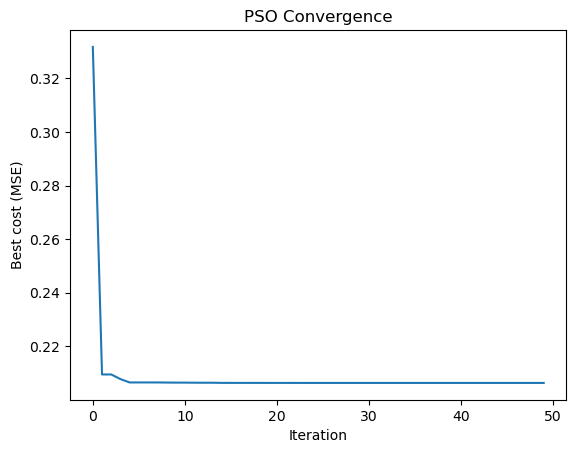

In [23]:
def pso_linear_regression(X, y, n_particles=30, n_iter=100, w_pso=0.5, c1=0.8, c2=0.9):
    """
    PSO to minimise MSE for linear regression.
    Each particle is (w0, w1).
    """
    n_dims = X.shape[1]
    # Initialise particles randomly around zero
    positions = np.random.randn(n_particles, n_dims) * 2
    velocities = np.random.randn(n_particles, n_dims) * 0.1
    personal_best_pos = positions.copy()
    personal_best_cost = np.array([cost_gradient(X, y, p)[0] for p in positions])
    global_best_idx = np.argmin(personal_best_cost)
    global_best_pos = personal_best_pos[global_best_idx].copy()
    global_best_cost = personal_best_cost[global_best_idx]
    
    cost_history = []
    for it in range(n_iter):
        for i in range(n_particles):
            r1, r2 = np.random.random(2)
            velocities[i] = (w_pso * velocities[i] +
                             c1 * r1 * (personal_best_pos[i] - positions[i]) +
                             c2 * r2 * (global_best_pos - positions[i]))
            positions[i] = positions[i] + velocities[i]
            current_cost, _ = cost_gradient(X, y, positions[i])
            if current_cost < personal_best_cost[i]:
                personal_best_cost[i] = current_cost
                personal_best_pos[i] = positions[i].copy()
                if current_cost < global_best_cost:
                    global_best_cost = current_cost
                    global_best_pos = positions[i].copy()
        cost_history.append(global_best_cost)
        if it % 20 == 0:
            print(f"PSO iter {it}: best cost = {global_best_cost:.6f}")
    return global_best_pos, global_best_cost, cost_history

w_pso, cost_pso, pso_hist = pso_linear_regression(X_train, y_train, n_iter=50)
print(f"\nPSO best weights: w0 = {w_pso[0]:.6f}, w1 = {w_pso[1]:.6f}")
print(f"PSO best cost (MSE) = {cost_pso:.6f}")

# Optional: plot PSO convergence
plt.plot(pso_hist)
plt.xlabel('Iteration')
plt.ylabel('Best cost (MSE)')
plt.title('PSO Convergence')
plt.show()